In [1]:
import os
import random
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models

In [3]:
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.2
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
train_dir = '/Users/piyushagarwal/Documents/Python Files/CV/cs-460-muffin-vs-chihuahua-classification-challenge/train'
test_dir = '/Users/piyushagarwal/Documents/Python Files/CV/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final'

In [5]:
muffin_count = len(os.listdir(os.path.join(train_dir, "muffin")))
chihuahua_count = len(os.listdir(os.path.join(train_dir, "chihuahua")))

total = muffin_count + chihuahua_count

print("Muffin images:", muffin_count)
print("Chihuahua images:", chihuahua_count)
print("Total images:", total)

print("\nClass distribution:")
print("Muffin:", muffin_count/total*100, "%")
print("Chihuahua:", chihuahua_count/total*100, "%")

Muffin images: 2174
Chihuahua images: 2559
Total images: 4733

Class distribution:
Muffin: 45.93281216987112 %
Chihuahua: 54.06718783012888 %


In [6]:
train_datagen = ImageDataGenerator(
    
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

In [7]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 3788 images belonging to 2 classes.


In [9]:
validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 945 images belonging to 2 classes.


In [10]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), padding='same', input_shape=(256,256,3)),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-08 20:53:34.023755: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-08 20:53:34.023778: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-08 20:53:34.023781: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-08 20:53:34.023795: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 20:53:34.023804: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.c

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,721 (64.36 MB)

 Trainable params: 16,870,721 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10


2026-04-08 20:53:34.883387: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.6204 - loss: 1.3944 - val_accuracy: 0.8127 - val_loss: 0.4453
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.7379 - loss: 0.5830 - val_accuracy: 0.8466 - val_loss: 0.4054
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 236ms/step - accuracy: 0.7759 - loss: 0.5774 - val_accuracy: 0.8889 - val_loss: 0.2830
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 250ms/step - accuracy: 0.7941 - loss: 0.5056 - val_accuracy: 0.8783 - val_loss: 0.3038
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 278ms/step - accuracy: 0.8076 - loss: 0.4947 - val_accuracy: 0.8974 - val_loss: 0.2737
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 35s 292ms/step - accuracy: 0.8149 - loss: 0.4814 - val_accuracy: 0.9111 - val_loss: 0.2353
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 287ms/step - accuracy: 0.8279 - loss: 0.4599 - val_accuracy: 0.8889 - val_loss: 0.2786
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 281ms/step - accuracy: 0.8297 - loss: 0.4551 - val

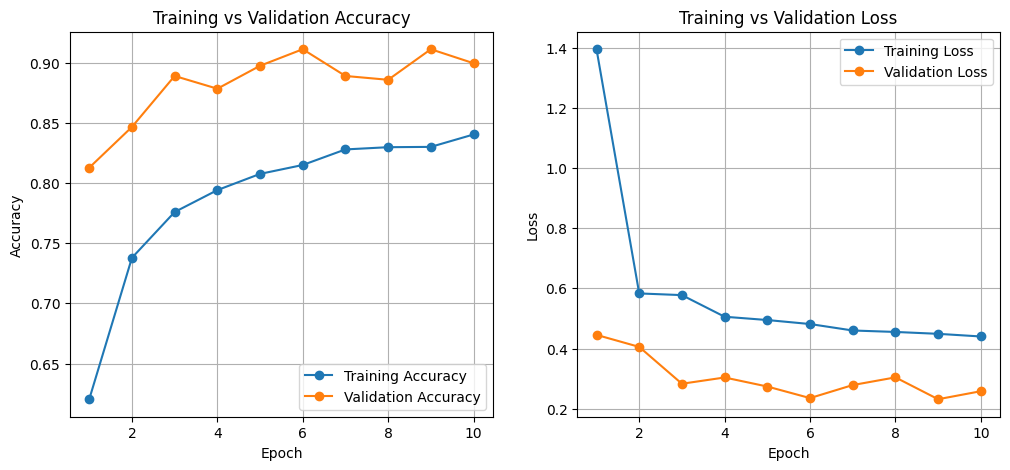

In [14]:
# Accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()